# Cryptanalyse différentielle de PRESENT par SAT

**EPITA 2026 - Programmation par Contraintes - Projet F2**

In [1]:
# Imports
import sys
sys.path.insert(0, '.')

from present_sat.present import SBOX, P, DDT, encrypt, generate_round_keys, validate_trail
from present_sat.encoding import (
    build_model, build_weighted_model,
    _SBOX_PI_TEMPLATES, _SBOX_WEIGHT_TEMPLATES,
    trail_weight, trail_active_sboxes
)
from present_sat.search import find_min_active_sbox, find_min_trail_weight, ACTIVE_BOUNDS

import json
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D


In [2]:
# Load le fichier de benchmark
with open("benchmark.json", "r") as f:
    benchmark = json.load(f)

## 1 - Introduction

### 1.a - Contexte

La **cryptanalyse différentielle** est une attaque générique contre les chiffrements par blocs, introduite par Biham et Shamir en 1991. Elle consiste à étudier comment une différence $\Delta = M \oplus M'$ entre deux textes clairs se propage à travers les tours du chiffrement.

On appelle *trajectoire différentielle* une suite $(\Delta_0, \Delta_1, \ldots, \Delta_R)$ où $\Delta_r$ est la différence entre deux états après le $r$-ième tour. Chaque transition $\Delta_r \to \Delta_{r+1}$ est probabiliste et dépend des composants non-linéaires du chiffrement.

Le **poids** d'une trajectoire est défini par $w = -\log_2(\text{prob})$, où $\text{prob} = \prod_i p_i$ est le produit des probabilités de chaque transition. Un poids élevé signifie que la trajectoire est peu probable, et donc difficile à exploiter.

À l'inverse, une trajectoire de faible poids a une probabilité élevée : un attaquant peut collecter suffisamment de paires de textes clairs suivant cette trajectoire pour en déduire des bits de clé, bien plus efficacement qu'une recherche exhaustive.

**Critère de sécurité :** si $w_{\min}(R) > n$ (taille du bloc en bits), le chiffrement résiste à la cryptanalyse différentielle sur $R$ tours. En effet, exploiter une trajectoire de poids $w$ requiert environ $2^{w+1}$ paires de textes clairs. Pour PRESENT ($n = 64$), l'espace des textes clairs est de taille $2^{64}$ : dès que $w > 64$, la complexité en données dépasse $2^{65}$, ce qui est hors de portée de tout attaquant.


### 1.b - Le chiffrement PRESENT

PRESENT (Bogdanov et al., 2007) est un chiffrement par blocs ultra-léger, conçu pour les environnements contraints (IoT, RFID). Il opère sur des blocs de **64 bits** avec une clé de **80 bits** et se compose de **31 tours** identiques.

#### Architecture - Structure SPN

Chaque tour enchaîne trois opérations :

1. **AddRoundKey** : XOR de l'état courant avec les 64 bits de sous-clé extraits du registre de clé
2. **sBoxLayer** : application parallèle de 16 S-boxes identiques $S : \{0,1\}^4 \to \{0,1\}^4$, une par nibble
3. **pLayer** : permutation bit fixe $P : \{0,\ldots,63\} \to \{0,\ldots,63\}$ qui mélange les sorties des 16 S-boxes (le dernier tour n'applique pas le pLayer)

<div style="text-align: center;"><br/><img src="images/present-1.png" width="40%"/><br/><em>Description algorithmique de PRESENT</em></div>

#### Propagation des différences

Dans un SPN, les différences se propagent de façon probabiliste à travers les S-boxes. Pour une S-box $S$, la probabilité que la différence d'entrée $a$ produise la différence de sortie $b$ est :
$$\Pr[\Delta_{\text{out}} = b \mid \Delta_{\text{in}} = a] = \frac{\#\{x \mid S(x) \oplus S(x \oplus a) = b\}}{2^n}$$
Cette quantité correspond à $\text{DDT}[a][b] / 16$, où la DDT est construite en section 2.

#### Propriété clé pour la cryptanalyse différentielle

L'opération `AddRoundKey` **disparaît** dans le calcul de différences. Pour deux textes $A$ et $A' = A \oplus \Delta$ :
$$\Delta(A \oplus K) = (A \oplus K) \oplus (A' \oplus K) = A \oplus A' = \Delta$$
La propagation des différences est donc **indépendante de la clé secrète**, ce qui rend l'analyse possible sans la connaître.

#### S-boxes actives et borne inférieure sur le poids

Le `pLayer` est une permutation linéaire : la différence en sortie est entièrement déterminée par la différence en entrée, $\Delta_{\text{out}} = P(\Delta_{\text{in}})$, avec probabilité 1. L'`AddRoundKey` ne modifie pas non plus les différences, comme on vient de le voir. **Toute l'incertitude probabiliste d'une trajectoire provient donc des S-boxes seules.**

Le poids d'une trajectoire se décompose alors en une somme sur les S-boxes traversées au cours des $R$ tours :
$$w(\Delta_0, \ldots, \Delta_R) = \sum_{r=0}^{R-1} \sum_{i=1}^{16} w_S\!\left(\Delta_r^{(i)} \to \Delta_{r+1}^{(i)}\right)$$
où $\Delta_r^{(i)}$ est la différence en entrée de la $i$-ème S-box au tour $r$.

Une S-box est dite *active* dans une trajectoire si sa différence d'entrée est non nulle. Une S-box inactive subit la transition $0 \to 0$, déterministe et de poids nul ; elle ne contribue pas au poids total.

L'examen de la DDT de PRESENT (construite en section 2) montre que toute transition non triviale a une probabilité d'au plus $2^{-2}$. Autrement dit, **chaque S-box active contribue un poids d'au moins 2**. Si on note $A(R)$ le nombre minimum de S-boxes actives sur l'ensemble des trajectoires à $R$ tours, on obtient :
$$w_{\min}(R) \geq 2 \cdot A(R)$$

Cette borne est doublement utile :

- **Elle se calcule plus facilement que $w_{\min}$.** Déterminer $A(R)$ ne fait intervenir que la propagation des bits actifs à travers le `pLayer` - un problème purement combinatoire sur des variables binaires (S-box active ou non), indépendant des valeurs de la DDT. Le modèle SAT correspondant est nettement plus léger.
- **Elle fournit un argument de sécurité a priori.** Si l'on prouve $A(R) \geq k$, alors aucune trajectoire sur $R$ tours ne peut avoir un poids inférieur à $2k$, sans avoir à les énumérer. C'est l'argument utilisé par Bogdanov et al. dans la spécification de PRESENT pour justifier la résistance du chiffrement.

En revanche, cette borne n'est pas toujours atteinte : certaines configurations forcent des transitions de poids supérieur à 2 (par exemple lorsque les bits actifs d'entrée et de sortie sont contraints à des positions incompatibles avec les transitions optimales de la DDT). Calculer $w_{\min}(R)$ exactement - et non seulement le borner - demande d'encoder la DDT complète dans le modèle. Les deux quantités $A(R)$ et $w_{\min}(R)$ feront donc l'objet de modèles SAT distincts dans la suite du projet.

In [3]:
# Les S-box et la P-layer de PRESENT

print("S-box PRESENT :")
print(' '.join(f'{v:X}' for v in range(16)))
print(' '.join(f'{v:X}' for v in SBOX))
print()
print("P-layer (bit i -> position P[i]) :")
for row in range(4):
    print(' '.join(f'{P[16*row+col]:2d}' for col in range(16)))

S-box PRESENT :
0 1 2 3 4 5 6 7 8 9 A B C D E F
C 5 6 B 9 0 A D 3 E F 8 4 7 1 2

P-layer (bit i -> position P[i]) :
 0 16 32 48  1 17 33 49  2 18 34 50  3 19 35 51
 4 20 36 52  5 21 37 53  6 22 38 54  7 23 39 55
 8 24 40 56  9 25 41 57 10 26 42 58 11 27 43 59
12 28 44 60 13 29 45 61 14 30 46 62 15 31 47 63


In [4]:
# Vecteurs de test présents dans le papier de référence (papers/present-an-ultra-lightweight-block-cipher.pdf)
tests = [
    (0x0000000000000000, 0x00000000000000000000, 0x5579C1387B228445),
    (0x0000000000000000, 0xFFFFFFFFFFFFFFFFFFFF, 0xE72C46C0F5945049),
    (0xFFFFFFFFFFFFFFFF, 0x00000000000000000000, 0xA112FFC72F68417B),
    (0xFFFFFFFFFFFFFFFF, 0xFFFFFFFFFFFFFFFFFFFF, 0x3333DCD3213210D2),
]
for pt, k, expected in tests:
    ct = encrypt(pt, generate_round_keys(k))
    status = "ok" if ct == expected else f"ERREUR (got {ct:016X})"
    print(f"P={pt:016X}  K={k:020X}  ->  C={ct:016X}  {status}")

P=0000000000000000  K=00000000000000000000  ->  C=5579C1387B228445  ok
P=0000000000000000  K=FFFFFFFFFFFFFFFFFFFF  ->  C=E72C46C0F5945049  ok
P=FFFFFFFFFFFFFFFF  K=00000000000000000000  ->  C=A112FFC72F68417B  ok
P=FFFFFFFFFFFFFFFF  K=FFFFFFFFFFFFFFFFFFFF  ->  C=3333DCD3213210D2  ok


### 1.c - Problématique

> **PRESENT résiste-t-il à la cryptanalyse différentielle, et à partir de combien de tours ?**

Plus précisément, ce projet cherche à répondre aux questions suivantes :

1. Quel est le **nombre minimum de S-boxes actives** dans tout chemin différentiel sur $R$ tours ?
2. Quel est le **poids minimum** de ce chemin, c'est-à-dire la meilleure probabilité différentielle atteignable ?
3. À partir de quel $R$ ce poids dépasse-t-il 64, rendant toute attaque impraticable ?
4. Est-il possible d'**extraire automatiquement** un chemin optimal à partir du modèle SAT ?

L'approche adoptée consiste à encoder ces contraintes sous forme de formule SAT et à utiliser un solveur pour obtenir des réponses exactes.


### 1.d - Littérature et résultats attendus

#### Nombre minimum de S-BOXES actives:
Bogdanov et al. (CHES 2007) prouvent que tout chemin différentiel sur $R$ tours de PRESENT active au moins $2R$ S-boxes (pour $R \geq 2$). Des analyses ultérieures précisent les poids minimaux exacts.

#### Poids minimum des trajectoires différentielles:
Le tableau ci-dessous (issues de la littérature - *papers/accelrating-the-best-trail-search-on-aes-like-ciphers.pdf*) décrit les poids différentiels minimum en fonction de R:

*La colonne qui nous intéresse ici est B[R].*

<div style="text-align: center;"><br/><img src="images/present-2.png" width="50%"/><br/><em>Meilleurs poids différentiels de PRESENT</em></div>


On peut noter qu'à partir de $R > 14$, le poids minimum est supérieur à $64$. On peut également noter que les temps de calcul sont très faible comparé aux résultats présentés plus bas. Cela est dû au fait que c'est une approche par DFS qui est utilisée ici et non une résolution de problème SAT, moins performante que le DFS branch-and-bound pour ce problème précis.

## 2 - Modélisation

Cette section décrit la modélisation choisie : on commence par caractériser le comportement différentiel de la S-box via la DDT, puis on présente l'encodage en clauses SAT et les algorithmes de recherche utilisés.


### 2.a - Table de Distribution des Différences (DDT)

Pour encoder les contraintes différentielles en SAT, il faut d'abord caractériser le comportement de la S-box face aux différences. La **DDT** remplit ce rôle :
$$\text{DDT}[a][b] = \left|\{ x \in \{0,\ldots,15\} : S(x) \oplus S(x \oplus a) = b \}\right|$$

La valeur $\text{DDT}[a][b]$ compte le nombre d'entrées $x$ pour lesquels la différence d'entrée $a$ produit la différence de sortie $b$. La probabilité associée est $\text{DDT}[a][b]/16$.

Pour PRESENT, les seules valeurs non nulles (pour $a \neq 0$) sont 2 et 4 :

| DDT | probabilité | poids $w = -\log_2(p)$ | interprétation |
|-----|------------|----------------------|----------------|
| 0   | 0          | $\infty$             | transition impossible |
| 2   | 1/8        | **3**                | transition *lourde* |
| 4   | 1/4        | **2**                | transition *normale* |

La ligne $a = 0$ correspond aux différences passives, qui se propagent trivialement et n'interviennent pas dans l'analyse.


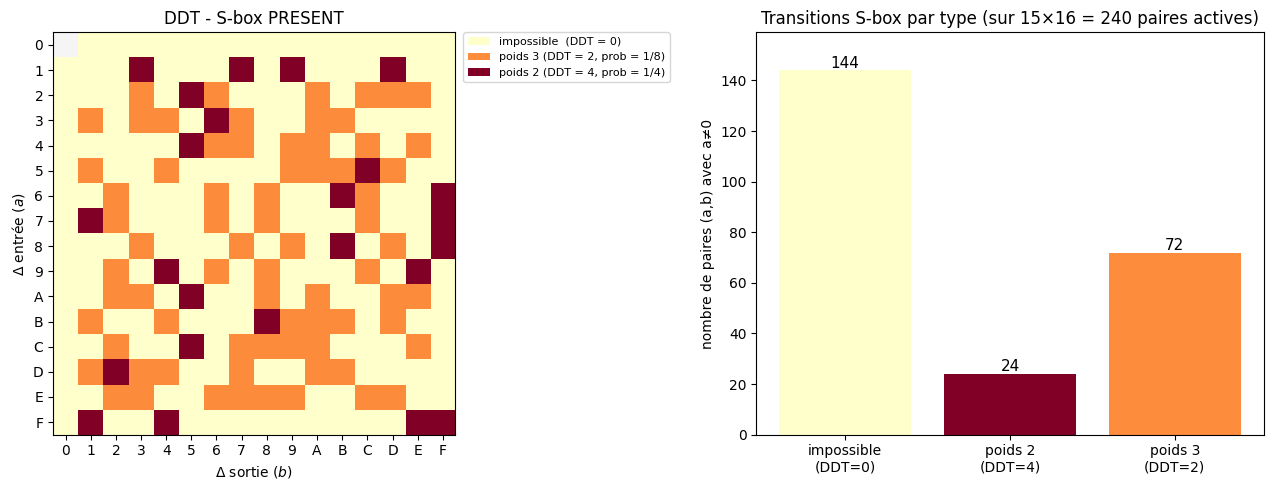

MDP = 4/16 = 1/4  =>  poids min par S-box active = 2
Transitions actives : 96  (dont 72 lourdes DDT=2)


In [5]:
# Affichage de la DDT de la S-box PRESENT

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
cmap = plt.cm.YlOrRd
norm = plt.Normalize(vmin=0, vmax=4)
ddt_display = np.array(DDT, dtype=float)
ddt_display[0, 0] = np.nan
cmap.set_bad("whitesmoke")
ax.imshow(ddt_display, cmap=cmap, norm=norm, aspect='equal')

ax.set_xticks(range(16)); ax.set_xticklabels([f'{i:X}' for i in range(16)])
ax.set_yticks(range(16)); ax.set_yticklabels([f'{i:X}' for i in range(16)])
ax.set_xlabel('$\\Delta$ sortie ($b$)')
ax.set_ylabel('$\\Delta$ entrée ($a$)')
ax.set_title('DDT - S-box PRESENT')

ax.legend(handles=[
    Patch(facecolor=cmap(norm(0)), label='impossible  (DDT = 0)'),
    Patch(facecolor=cmap(norm(2)), label='poids 3 (DDT = 2, prob = 1/8)'),
    Patch(facecolor=cmap(norm(4)), label='poids 2 (DDT = 4, prob = 1/4)'),
], fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

impossible = sum(1 for a in range(1, 16) for b in range(16) if DDT[a][b] == 0)
w2_count   = sum(1 for a in range(1, 16) for b in range(16) if DDT[a][b] == 4)
w3_count   = sum(1 for a in range(1, 16) for b in range(16) if DDT[a][b] == 2)

ax2 = axes[1]
bars = ax2.bar(
    ['impossible\n(DDT=0)', 'poids 2\n(DDT=4)', 'poids 3\n(DDT=2)'],
    [impossible, w2_count, w3_count],
    color=[cmap(norm(0)), cmap(norm(4)), cmap(norm(2))]
)
for bar, val in zip(bars, [impossible, w2_count, w3_count]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
             ha='center', fontsize=11)
ax2.set_ylabel('nombre de paires (a,b) avec a≠0')
ax2.set_title('Transitions S-box par type (sur 15×16 = 240 paires actives)')
ax2.set_ylim(0, max(impossible, w2_count, w3_count) + 15)

plt.tight_layout()
plt.show()
print(f"MDP = {DDT[1:].max()}/16 = 1/4  =>  poids min par S-box active = 2")
print(f"Transitions actives : {w2_count + w3_count}  (dont {w3_count} lourdes DDT=2)")


### 2.b - Encodage SAT

Un chemin différentiel sur $R$ tours est un tuple $(\Delta_0, \Delta_1, \ldots, \Delta_R)$ où chaque $\Delta_r$ est un vecteur de 64 bits. Pour chaque S-box $s$ au tour $r$, la paire (entrée, sortie) doit vérifier $\text{DDT}[a][b] > 0$.

L'approche consiste à encoder chaque contrainte $\text{DDT}[a][b] = 0$ comme une clause SAT interdisant l'affectation $(\text{entrée}=a, \text{sortie}=b)$. Un solveur SAT (CaDiCaL ou Kissat) peut alors trouver un chemin valide ou prouver qu'il n'en existe pas.

#### Variables SAT

Trois familles de variables booléennes sont introduites :

| Variable | Formule | Sémantique |
|---|---|---|
| `diff_var(r, i)` | $1 + r \cdot 64 + i$ | bit $i$ de $\Delta_r$ |
| `active_var(R, r, s)` | offset + $r \cdot 16 + s$ | 1 si la S-box $s$ au tour $r$ est active ($\Delta \neq 0$) |
| `heavy_var(R, r, s)` | offset + $R \cdot 16 + r \cdot 16 + s$ | 1 si la transition a DDT=2 (poids 3 au lieu de 2) |

Le poids total d'un chemin vaut $\sum_s 2 \cdot \text{active} + \text{heavy}$, ce qui permet d'exprimer une contrainte pseudo-booléenne `atmost` sur le poids total.

#### Optimisation : Quine-McCluskey (QM)

L'approche naïve génère une clause par paire invalide $(a, b)$ avec $\text{DDT}[a][b] = 0$. Sur 8 bits (4 pour $a$, 4 pour $b$), cela représente environ 160 clauses par S-box. Le calcul devient alors trop long à partir de R > 10 (environ 3h).

L'algorithme de **Quine-McCluskey** réduit ce nombre en regroupant plusieurs minterms invalides en un seul *prime implicant* : si deux minterms ne diffèrent que d'un seul bit et qu'aucun minterm valide ne se trouve dans leur voisinage, ils peuvent être fusionnés en un terme avec ce bit en « don't care ». Le processus est répété jusqu'à saturation, puis un sous-ensemble minimal de prime implicants est sélectionné pour couvrir tous les minterms invalides.

Par exemple, si $(a=\texttt{0001}, b=\texttt{0011})$ et $(a=\texttt{0001}, b=\texttt{0111})$ sont tous les deux invalides, ils sont fusionnés en $a=\texttt{0001}, b=\texttt{\_011}$ - une seule clause au lieu de deux.


In [6]:
# Comparaison : encodage naïf et QM
naive_count = sum(1 for a in range(16) for b in range(16) if DDT[a][b] == 0)
qm_8bit  = len(_SBOX_PI_TEMPLATES)
qm_10bit = len(_SBOX_WEIGHT_TEMPLATES)

print(f"Encodage naïf            : {naive_count:3d} clauses / S-box")
print(f"QM 8-bit  (build_model)  : {qm_8bit:3d} clauses / S-box  (gain ×{naive_count/qm_8bit:.1f})")
print(f"QM 10-bit (weighted)     : {qm_10bit:3d} clauses / S-box")
print()
# CNF sizes for R=1..5
print(f"{'R':>3}  {'vars':>6}  {'clauses (build_model)':>22}  {'clauses (weighted)':>20}")
print("-" * 58)
for r in range(1, 6):
    m  = build_model(r)
    mw = build_weighted_model(r)
    print(f"{r:>3}  {m.nv:>6}  {len(m.clauses):>22}  {len(mw.clauses):>20}")

Encodage naïf            : 159 clauses / S-box
QM 8-bit  (build_model)  :  41 clauses / S-box  (gain ×3.9)
QM 10-bit (weighted)     :  64 clauses / S-box

  R    vars   clauses (build_model)    clauses (weighted)
----------------------------------------------------------
  1     144                     738                  1026
  2     224                    1474                  2050
  3     304                    2210                  3074
  4     384                    2946                  4098
  5     464                    3682                  5122


**Nous avons donc maintenant un modèle complet et (relativement) optimisé. Il ne nous manque plus qu'un algorithme de recherche efficace.**

### 2.c — Algorithmes de recherche

Deux algorithmes successifs exploitent le modèle CNF pour calculer les bornes optimales.

**Algorithme 1 — S-boxes actives minimales** (`find_min_active_sbox`)

Une **recherche binaire** est effectuée sur $k$ : à chaque itération, la contrainte `CardEnc.atmost(active_vars, bound=k)` est ajoutée au CNF de base, encodée via un **littéral d'hypothèse** (*assumption*) pour pouvoir être retirée à l'itération suivante sans reconstruire le problème. Complexité : $O(\log(16R))$ appels SAT.

**Algorithme 2 — Poids minimum** (`find_min_trail_weight`)

1. On calcule $k^* = \text{min\_active}(R)$, ce qui donne la borne inférieure $W_{\min} \geq 2k^*$ (et $W_{\min} \geq W_{\min}(R{-}1) + 2$ puisque chaque tour supplémentaire contribue au moins 2).
2. Une **recherche linéaire ascendante** teste $W = W_{\text{lo}}, W_{\text{lo}}+1, \ldots$ en ajoutant `PBEnc.atmost(lits, weights, bound=W)` jusqu'à obtenir SAT.

La contrainte pseudo-booléenne encode $\sum_{s,r} 2 \cdot a_{s,r} + h_{s,r} \leq W$, avec $a_{s,r}$ = `active_var` (poids 2) et $h_{s,r}$ = `heavy_var` (poids supplémentaire 1 pour les transitions DDT=2).

**Choix du solveur.** Deux solveurs ont été comparés : **CaDiCaL**, qui supporte l'incrémentalité native (les clauses apprises sont conservées entre appels successifs sur la même instance), et **Kissat**, qui ne le supporte pas et reconstruit le solveur à chaque itération. En théorie, l'incrémentalité devrait favoriser CaDiCaL dans une recherche linéaire ascendante. En pratique, **Kissat reste significativement plus rapide** sur l'ensemble de nos instances (voir benchmarks en section 3.c). Nous utilisons donc Kissat comme solveur par défaut, malgré la perte du bénéfice théorique de la réutilisation des clauses apprises.

#### Optimisation de la borne inférieure

**Lemme.** Pour PRESENT, $w_{\min}(R) \geq w_{\min}(R-1) + 2$ pour tout $R \geq 2$.

*Preuve.* Soit une trajectoire optimale $\Delta_0 \to \cdots \to \Delta_R$ de poids $w_{\min}(R)$, avec $\Delta_0 \neq 0$. Le préfixe $\Delta_0 \to \cdots \to \Delta_{R-1}$ a un poids $\geq w_{\min}(R-1)$. Il suffit donc de montrer que le dernier tour contribue $\geq 2$, c'est-à-dire que $\Delta_{R-1} \neq 0$.

La S-box de PRESENT étant bijective, $\Delta X = 0 \Leftrightarrow \Delta Y = 0$ (Wei et al., ePrint 2012/214, Lemme 6). Le `pLayer` et l'`AddRoundKey` préservent la nullité. Si $\Delta_{R-1} = 0$, alors par récurrence arrière $\Delta_0 = 0$ - contradiction. Donc $\Delta_{R-1} \neq 0$, au moins une S-box est active au tour $R$, et contribue un poids $\geq 2$.

## 3 - Résultats

Les résultats sont présentés en trois parties : le nombre minimum de S-boxes actives, le poids minimum des chemins différentiels, puis l'extraction d'un chemin optimal. Pour $R \leq 8$, les calculs s'exécutent directement dans le notebook. Pour les valeurs plus grandes, les résultats sont mis en cache.


### 3.a - S-boxes actives minimales

Le nombre de S-boxes actives dans un chemin différentiel fournit une **borne inférieure sur le poids** : chaque S-box active contribue au moins 2, la probabilité maximale de la DDT étant 4/16 = 1/4. Minimiser ce nombre est donc une première étape avant de rechercher le poids exact.

La recherche binaire décrite en 2.c est appliquée avec CaDiCaL. Les temps de calcul croissent régulièrement avec $R$, avec quelques irrégularités (par exemple $R=28$ se résout plus vite que $R=27$), probablement dues aux clauses apprises par le solveur qui varient selon l'instance.


In [7]:
# Calcul du nombre minimal de S-Boxe active pour R=1..6
print(f"{'R':>3}  {'min_active':>10}  {'temps':>8}")
print("-" * 26)
for r in range(1, 7):
    t0 = time.time()
    k, _ = find_min_active_sbox(r, solver="cadical", return_trail=True)
    t = time.time() - t0
    print(f"{r:>3}  {k:>10}  {t:>7.3f}s")

  R  min_active     temps
--------------------------
  1           1    0.002s
  2           2    0.004s
  3           4    0.009s
  4           6    0.042s
  5          10    0.369s
  6          12    0.585s


Le temps de calcul pour les tours de 1 à 31 est d'environ 30 minutes. La table complète est affichée ci-dessous à partir du fichier benchmark.json.

In [8]:
# Résultats complets (Kissat, R=1..31)
# Temps total : environ 30 minutes.
print(f"{'R':>3}  {'min_active':>10}  {'temps':>10}")
print("-" * 27)


total_time = 0
for row in benchmark['min_active_kissat']:
    r = int(row)
    k = benchmark['min_active_kissat'][row]['min_active']
    t = benchmark['min_active_kissat'].get(str(r), {}).get('time')
    total_time += t
    print(f"{r:>3}  {k:>10}  {t:>9.3f}s")

print(f"\nmin_active(R) = 2R pour R ≥ 2  (sauf R=1 où min_active=1)")
print(f"Temps total : {total_time/60:.1f} min")


  R  min_active       temps
---------------------------
  1           1      0.002s
  2           2      0.008s
  3           4      0.036s
  4           6      0.143s
  5          10      0.578s
  6          12      1.636s
  7          14      1.492s
  8          16      3.292s
  9          18      4.999s
 10          20     10.887s
 11          22      8.395s
 12          24     13.879s
 13          26     21.770s
 14          28     21.770s
 15          30     27.854s
 16          32     47.221s
 17          34     50.054s
 18          36     59.023s
 19          38     74.243s
 20          40     65.174s
 21          42     83.117s
 22          44     99.815s
 23          46    113.013s
 24          48     93.366s
 25          50     91.685s
 26          52    137.346s
 27          54    117.982s
 28          56    120.660s
 29          58    166.530s
 30          60    153.061s
 31          62    169.384s

min_active(R) = 2R pour R ≥ 2  (sauf R=1 où min_active=1)
Temps total : 29.

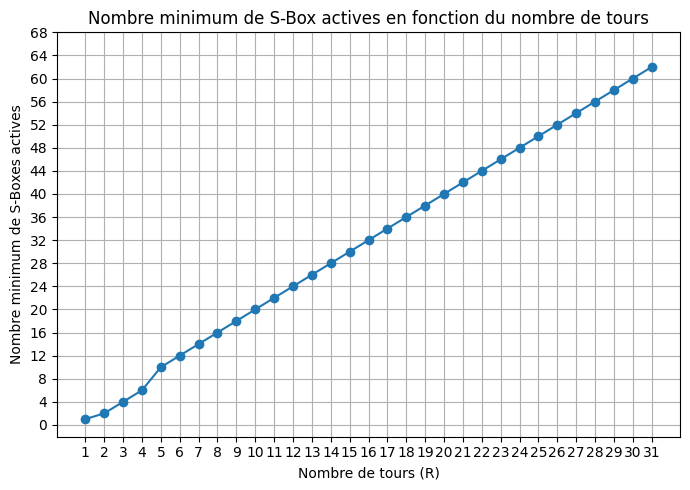

In [9]:
# Nombre minimum de S-Boxes actives en fonction du nombre de tours R
rounds = [i for i in range(1, 32)]
min_active = []

for r in benchmark['min_active_kissat']:
    min_active.append(benchmark['min_active_kissat'][r]['min_active'])

plt.figure(figsize=(7, 5))
plt.plot(rounds, min_active, marker='o')
plt.title('Nombre minimum de S-Box actives en fonction du nombre de tours')
plt.xlabel('Nombre de tours (R)')
plt.ylabel('Nombre minimum de S-Boxes actives')
plt.xticks(rounds)
plt.yticks(np.arange(0, 70, 4))
plt.grid()
plt.tight_layout()
plt.show()

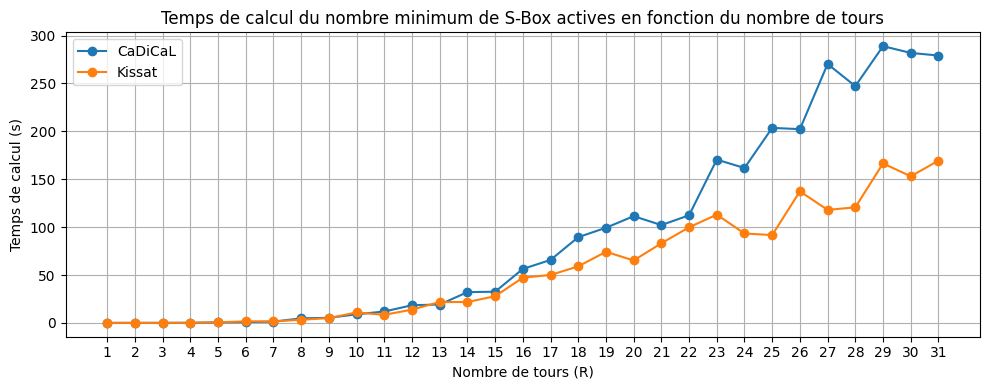

In [10]:
# Comparaison des temps de calcul du nombre minimum de S-Box en fonction du nombre de tours actives pour CaDiCaL et Kissat
rounds = [i for i in range(1, 32)]
cadical_times = []
kissat_times = []

for r in benchmark['min_active_cadical']:
    cadical_times.append(benchmark['min_active_cadical'][r]['time'])
for r in benchmark['min_active_kissat']:
    kissat_times.append(benchmark['min_active_kissat'][r]['time'])

plt.figure(figsize=(10, 4))
plt.plot(rounds, cadical_times, marker='o', label='CaDiCaL')
plt.plot(rounds, kissat_times, marker='o', label='Kissat')
plt.title('Temps de calcul du nombre minimum de S-Box actives en fonction du nombre de tours')
plt.xlabel('Nombre de tours (R)')
plt.ylabel('Temps de calcul (s)')
plt.xticks(rounds)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

*La commande utilisée est:* 
```sh
uv run python3 -m present_sat --active --rmax 31 --solver kissat
```

### 3.b - Poids minimum des chemins différentiels

Une fois le nombre minimum de S-boxes actives connu, on cherche le **poids minimum** réel d'un chemin sur $R$ tours, qui correspond à la meilleure probabilité différentielle atteignable.

On sait que $w_{\min}(R) \geq 2 \times \text{min\_active}(R)$, mais cette borne n'est pas toujours atteinte. Dans certains cas, la structure du chiffrement force au moins une transition DDT=2 (de poids 3 au lieu de 2), créant un **écart** entre la borne et le minimum réel.

C'est ce qu'on observe à partir de $R=10$ : le poids minimum est 41 alors que $2 \times 20 = 40$. Cet écart progresse par palier jusqu'à atteindre 12 à $R=26$.

**Résultat principal :** dès $R=15$, $w_{\min} = 66 > 64$. Toute attaque différentielle sur 15 tours ou plus nécessite plus de $2^{65}$ paires de textes clairs - ce qui dépasse la taille de l'espace des textes clairs. PRESENT est donc résistant à la cryptanalyse différentielle à partir de 15 tours.

Les calculs pour $R > 10$ peuvent prendre de quelques minutes à plusieurs heures ; les résultats sont mis en cache ci-dessous.


In [11]:
# Calcul du poids minimum pour R=1..10
# Environ 20s d'éxécution
print(f"{'R':>3} | {'2*min_active_sbox':17} | {'min_weight':>10} | {'temps':>8}  | {'gap':>3}")
print("-" * 55)
for r in range(1, 11):
    t0 = time.time()
    w = find_min_trail_weight(r)
    t = time.time() - t0
    bound = 2 * ACTIVE_BOUNDS[r]
    gap = w - bound
    print(f"{r:>3} | {bound:>17} | {w:>10} | {t:>8.3f}s | {gap:>3}  {'<' if gap else ''}")

  R | 2*min_active_sbox | min_weight |    temps  | gap
-------------------------------------------------------
  1 |                 2 |          2 |    0.003s |   0  
  2 |                 4 |          4 |    0.008s |   0  
  3 |                 8 |          8 |    0.046s |   0  
  4 |                12 |         12 |    0.083s |   0  
  5 |                20 |         20 |    0.159s |   0  
  6 |                24 |         24 |    0.878s |   0  
  7 |                28 |         28 |    0.867s |   0  
  8 |                32 |         32 |    1.547s |   0  
  9 |                36 |         36 |    4.275s |   0  
 10 |                40 |         41 |   12.979s |   1  <


On obsèrve bien qu'au tour 10, le gap entre 2 * min_active_sbox et min_weight est de 1. Donc une S-Boxe est forcée à être de poids 3 parmis les 20 actives.

In [12]:
# Résultats complets (Kissat, R=1..31)
print(f"{'R':>3}  {'min_active':>10}  {'2*active':>8}  {'min_weight':>10}  {'gap':>4}  {'temps':>11}")
print("-" * 56)

r_secure = sys.maxsize
w_secure = None
total_time = 0

for r in sorted(benchmark['min_weight_kissat_opti'], key=int):
    row = benchmark['min_weight_kissat_opti'][r]
    a = benchmark['min_active_cadical'][r]['min_active']
    w = row['min_weight']
    gap = w - 2 * a

    t = row['time']
    total_time += t

    suffix = ""
    if w > 64 and int(r) < r_secure:
        w_secure = w
        r_secure = int(r)
        suffix = "  <- seuil w > 64"

    print(f"{r:>3}  {a:>10}  {2*a:>8}  {w:>10}  {gap:>4}  {t:>10.3f}s{suffix}")

print()
print(f"Seuil de sécurité atteint à R={r_secure}  (w_min={w_secure} > 64)")
print(f"Temps total de calcul : {total_time/3600:.1f}h")


  R  min_active  2*active  min_weight   gap        temps
--------------------------------------------------------
  1           1         2           2     0       0.006s
  2           2         4           4     0       0.011s
  3           4         8           8     0       0.052s
  4           6        12          12     0       0.088s
  5          10        20          20     0       0.170s
  6          12        24          24     0       1.281s
  7          14        28          28     0       0.880s
  8          16        32          32     0       1.412s
  9          18        36          36     0       4.379s
 10          20        40          41     1      12.911s
 11          22        44          46     2     116.060s
 12          24        48          52     4      77.303s
 13          26        52          56     4     120.685s
 14          28        56          62     6     453.334s
 15          30        60          66     6     373.606s  <- seuil w > 64
 16          3

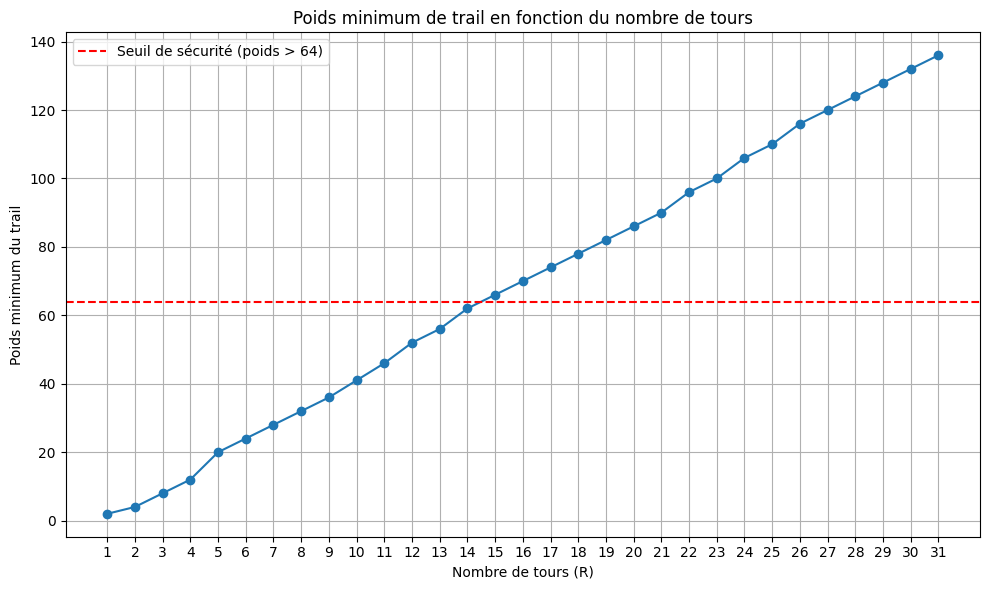

In [13]:
rounds = []
min_weights = []
for r in sorted(benchmark['min_weight_kissat_opti'], key=int):
    row = benchmark['min_weight_kissat_opti'][r]
    w = row['min_weight']
    rounds.append(int(r))
    min_weights.append(w)
plt.figure(figsize=(10, 6))
plt.plot(rounds, min_weights, marker='o')
plt.axhline(64, color='red', linestyle='--', label='Seuil de sécurité (poids > 64)')
plt.title('Poids minimum de trail en fonction du nombre de tours')
plt.xlabel('Nombre de tours (R)')
plt.ylabel('Poids minimum du trail')
plt.xticks(rounds)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

On remarque bien que le seuil de sécurité (poids > 64) est atteint à partir de R=15.

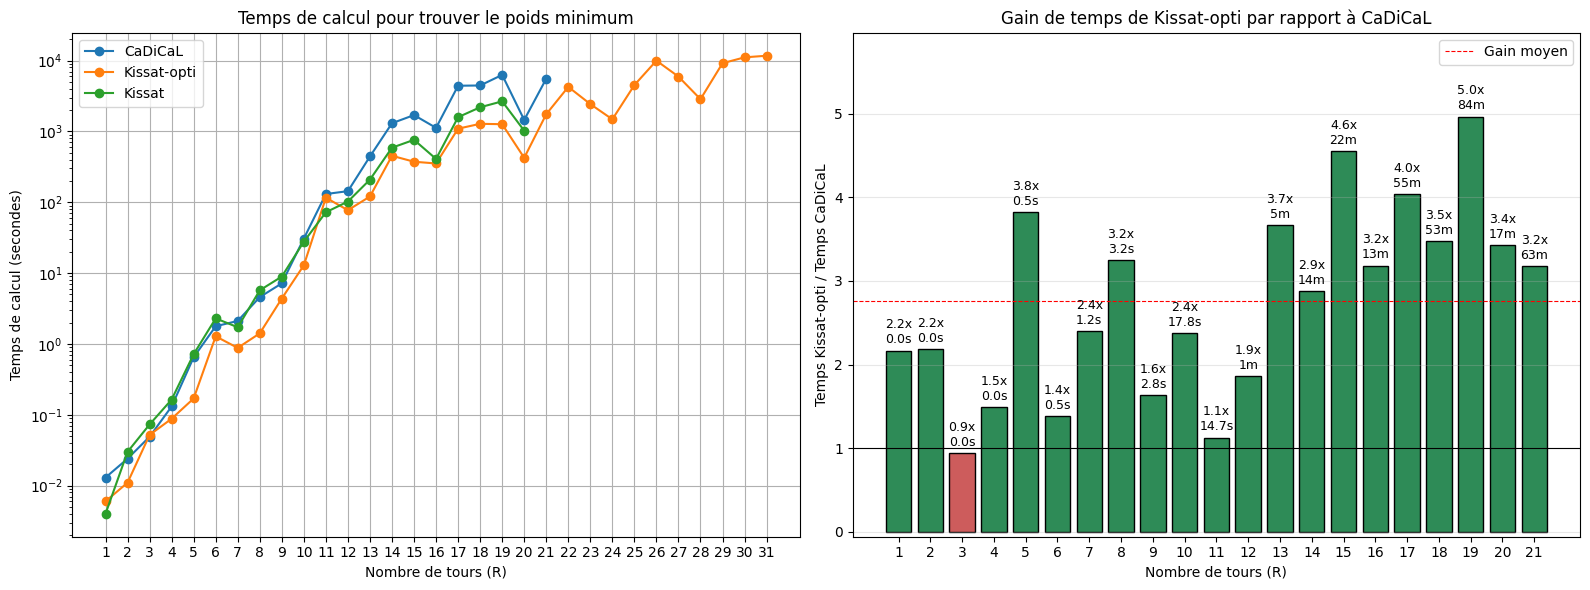

In [14]:

# Comparaison des solver CaDiCaL et Kissat pour le poids minimum de trail
fmt = lambda s: f"{s/60:.0f}m" if s >= 60 else f"{s:.1f}s"

r, tc, tko, tk, df, ds = [], [], [], [], [], []
for rk in sorted(benchmark['min_weight_kissat_opti'], key=int):
    ro = benchmark['min_weight_kissat_opti'][rk]
    rc = benchmark['min_weight_cadical'].get(rk, {'time': None})
    rk = int(rk)
    
    df.append(rc['time'] / ro['time'] if rc['time'] else None)
    ds.append(rc['time'] - ro['time'] if rc['time'] else None)
    
    r.append(rk)
    tc.append(rc['time'])
    tko.append(ro['time'])
    tk.append(benchmark['min_weight_kissat'].get(str(rk), {}).get('time'))

rd = [x for x, d in zip(r, df) if d]
df = [d for d in df if d]
ds = [s for s in ds if s]
c = ['seagreen' if d > 1 else 'indianred' for d in df]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(r, tc, 'o-', label='CaDiCaL')
ax1.plot(r, tko, 'o-', label='Kissat-opti')
ax1.plot(r, tk, 'o-', label='Kissat')
ax1.set(title='Temps de calcul pour trouver le poids minimum', 
        xlabel='Nombre de tours (R)', ylabel='Temps de calcul (secondes)',
        xticks=r, yscale='log')
ax1.grid(), ax1.legend()

bars = ax2.bar(rd, df, color=c, edgecolor='black')
ax2.axhline(1, color='black', linewidth=0.8)
ax2.axhline(np.mean(df), color='red', linestyle='--', linewidth=0.8, label='Gain moyen')

for bar, d, s in zip(bars, df, ds):
    h = bar.get_height()
    ax2.annotate(f"{d:.1f}x\n{fmt(abs(s))}", 
                 xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 3 if h > 0 else -3), textcoords='offset points',
                 ha='center', va=('bottom' if h > 0 else 'top'), fontsize=9)

ax2.set_ylim(min(df)-1, max(df)+1)
ax2.set(title='Gain de temps de Kissat-opti par rapport à CaDiCaL',
        xlabel='Nombre de tours (R)', ylabel='Temps Kissat-opti / Temps CaDiCaL',
        xticks=rd)
ax2.grid(axis='y', alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

Pour le problème donné, Kissat est **largement** supérieur à CaDiCaL (de 1.1 à 5 fois). 

Comme expliqué dans la section 2.b, nous utilisons une technique nous permettant d'avoir une meilleure approximation de la borne inférieure du poids minimum, ce qui réduit grandement le temps de calcul. **Kissat-opti** décrit les temps de calcul avec cette optimisation.


Néanmoins, l'utilisation de cette technique nécessite que le calcul des poids minimum soit exécuté séquentiellement, tour par tour. En effet, pour calculer la borne inférieur en R, il faut utiliser le poids minimum trouvé pour R-1. Il n'est donc plus possible de paralléliser l'éxecution dans ce cas précis.

### 3.c - Extraction d'un chemin différentiel optimal

Lorsque le solveur retourne SAT pour un poids $W$, son modèle (liste de littéraux positifs/négatifs) encode l'intégralité du chemin différentiel. La fonction `decode_trail` lit les variables `diff_var(r, i)` pour reconstruire les $R+1$ mots de 64 bits $\Delta_0, \ldots, \Delta_R$.

Pour valider le chemin extrait, on vérifie que pour chaque S-box $s$ et chaque tour $r$, la paire (nibble d'entrée, nibble de sortie après P-layer) satisfait bien $\text{DDT} > 0$. La sortie après P-layer est calculée comme suit :
$$b_j = \text{bit}_{P[4s+j]}(\Delta_{r+1}), \quad j = 0,\ldots,3$$

Le poids réel du chemin est ensuite calculé à partir des variables `active_var` et `heavy_var` du modèle : $w = \sum_{s,r} 2 \cdot a_{s,r} + h_{s,r}$.


In [15]:
# Calcul de la trajectoire différentielle
# Calcul des deux trajectoires
# Environ 15s d'éxécution
configs = [(7, "kissat"), (10, "cadical")]
trails = []

for R, solver in configs:
    t0 = time.time()
    W, trail = find_min_trail_weight(R, return_trail=True, solver=solver)
    elapsed = time.time() - t0
    weight = trail_weight(trail)

    print(f"Trail optimal - R={R}, poids W={W}  ({elapsed:.3f}s)\n")
    print(f"{'Tour':>6} | {'Δ_r':^18}")
    print("-" * 27)
    for i, delta in enumerate(trail):
        print(f"{i:>6} | {delta:#018x}")
    print(f"\nvalidate_trail  : {'ok' if validate_trail(trail, R) else 'INVALIDE'}")
    print(f"S-boxes actives : {trail_active_sboxes(trail)}")
    print(f"poids total     : {weight}  (attendu {W})")
    print(f"probabilité     : 2^(-{weight})")
    print("\n" + "=" * 40 + "\n")

    trails.append((trail, R, W))

Trail optimal - R=7, poids W=28  (0.818s)

  Tour |        Δ_r        
---------------------------
     0 | 0x000d00000000000d
     1 | 0x0000000010010000
     2 | 0x0090000000000090
     3 | 0x0000200200000000
     4 | 0x0000090000000900
     5 | 0x0000040400000000
     6 | 0x0000050000000500
     7 | 0x0404040400000000

validate_trail  : ok
S-boxes actives : 14
poids total     : 28.0  (attendu 28)
probabilité     : 2^(-28.0)


Trail optimal - R=10, poids W=41  (15.734s)

  Tour |        Δ_r        
---------------------------
     0 | 0x0000000000007007
     1 | 0x0000000000000009
     2 | 0x0000000100000000
     3 | 0x0100000000000100
     4 | 0x4004000000004004
     5 | 0x0000900900009009
     6 | 0x0000090900000000
     7 | 0x0000050000000000
     8 | 0x0000040000000000
     9 | 0x0000040000000400
    10 | 0x0000040400000404

validate_trail  : ok
S-boxes actives : 20
poids total     : 41.0  (attendu 41)
probabilité     : 2^(-41.0)




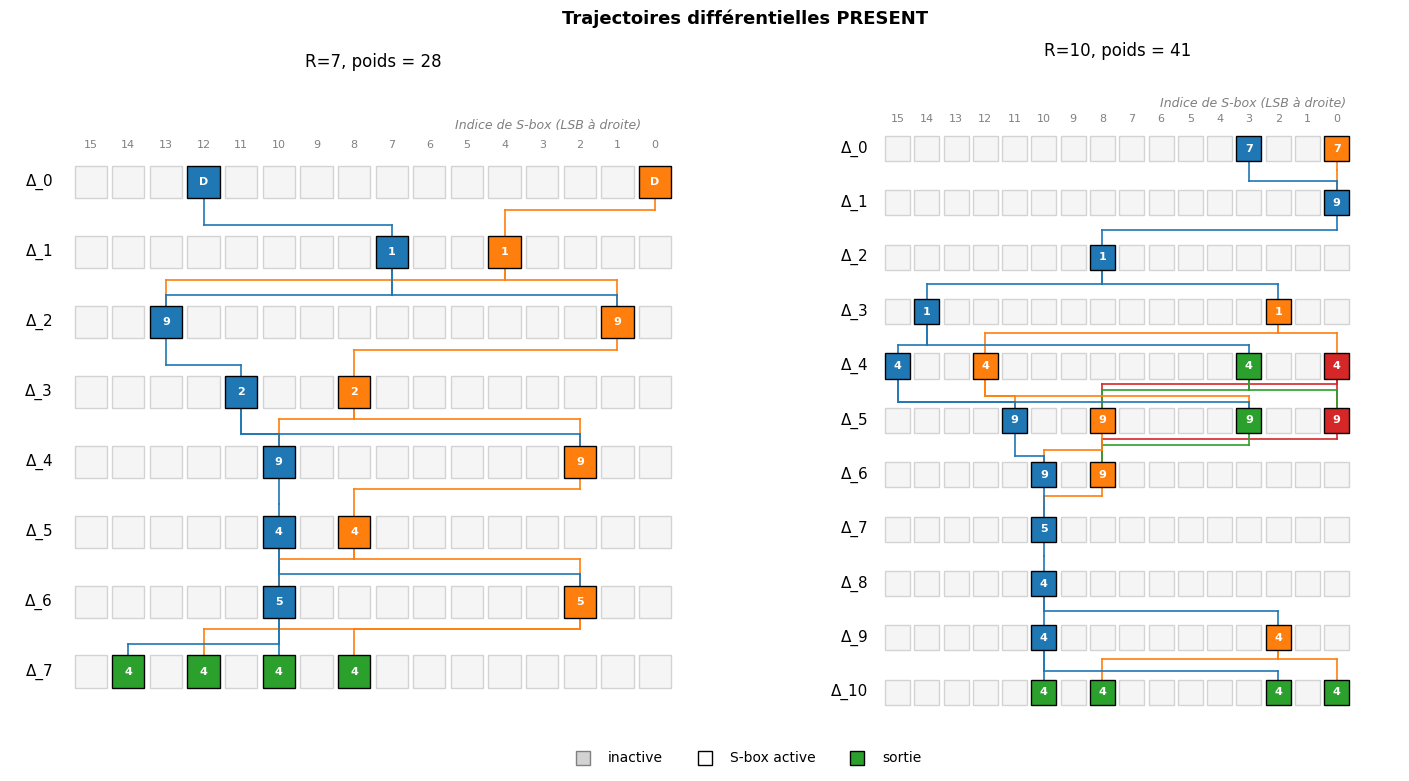

In [16]:
# Affichage des trajectoires différentiells
def out_nibble(s, d_out):
    return (d_out >> (4 * s)) & 0xF

P_COL = plt.get_cmap('tab10').colors
SQ, ROW, COL, BAND = 0.6, 1.3, 0.7, (1.3 - 0.6) * 0.8

xp = lambda s: (15 - s) * COL
yp = lambda r: -r * ROW


def plot_trail(ax, trail, R, W):
    a, w, i = [], [], []
    for r in range(R):
        d_in, d_out = trail[r], trail[r + 1]
        al, wd, id_ = [], {}, {}
        for s in range(16):
            nib = (d_in >> (4 * s)) & 0xF
            if nib:
                al.append(s)
                id_[s], b = nib, out_nibble(s, d_out)
                wd[s] = 2 if DDT[nib][b] == 4 else 3
        a.append(al); w.append(wd); i.append(id_)

    fo = {s: (trail[R] >> (4*s)) & 0xF for s in range(16) if (trail[R] >> (4*s)) & 0xF}
    gc = lambda r, s: P_COL[sorted(a[r], key=xp).index(s) % 10]

    for r in range(R):
        for s_src in a[r]:
            sa = sorted(a[r], key=xp)
            idx, n = sa.index(s_src), len(a[r])
            offset = -BAND/2 + (idx + 0.5) * (BAND / n)
            y1, y2 = yp(r) - SQ/2, yp(r+1) + SQ/2
            ym = (y1 + y2) / 2 + offset
            x1, col = xp(s_src), gc(r, s_src)
            for k in range(4):
                if (trail[r+1] >> P[4*s_src + k]) & 1:
                    s_dst = P[4*s_src + k] // 4
                    if (r+1 < R and s_dst in a[r+1]) or (r+1 == R and s_dst in fo):
                        x2 = xp(s_dst)
                        ax.plot([x1, x1], [y1, ym], color=col, lw=1.2, zorder=1)
                        ax.plot([x1, x2], [ym, ym], color=col, lw=1.2, zorder=1)
                        ax.plot([x2, x2], [ym, y2], color=col, lw=1.2, zorder=1)

    for r in range(R):
        for s in range(16):
            x, y = xp(s), yp(r)
            if s in a[r]:
                ax.add_patch(Rectangle((x-SQ/2, y-SQ/2), SQ, SQ, fc=gc(r,s), ec='black', zorder=3))
                ax.text(x, y, f"{i[r][s]:X}", ha='center', va='center', fontsize=8, color='white', fontweight='bold', zorder=4)
            else:
                ax.add_patch(Rectangle((x-SQ/2, y-SQ/2), SQ, SQ, fc='whitesmoke', ec='lightgray', zorder=3))

    for s in range(16):
        x, y = xp(s), yp(R)
        if s in fo:
            ax.add_patch(Rectangle((x-SQ/2, y-SQ/2), SQ, SQ, fc='C2', ec='black', zorder=3))
            ax.text(x, y, f"{fo[s]:X}", ha='center', va='center', fontsize=8, color='white', fontweight='bold', zorder=4)
        else:
            ax.add_patch(Rectangle((x-SQ/2, y-SQ/2), SQ, SQ, fc='whitesmoke', ec='lightgray', zorder=3))

    for r in range(R + 1):
        ax.text(-0.7, yp(r), f"Δ_{r}", ha='right', va='center', fontsize=11)
    for s in range(16):
        ax.text(xp(s), 0.7, str(s), ha='center', va='center', fontsize=8, color='gray')
    ax.text(8.5, 1, "Indice de S-box (LSB à droite)", ha='center', fontsize=9, color='gray', style='italic')
    ax.set_title(f"R={R}, poids = {W}")
    ax.set_xlim(-1.5, 12); ax.set_ylim(yp(R) - 0.9, 2)
    ax.set_aspect('equal'); ax.axis('off')


(trail1, R1, W1), (trail2, R2, W2) = trails
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
plot_trail(axes[0], trail1, R1, W1)
plot_trail(axes[1], trail2, R2, W2)

# Légende commune en bas
handles = [Line2D([0],[0], marker='s', color='w', markerfacecolor=c, markeredgecolor=e, markersize=10, label=l)
           for c, e, l in [('lightgray','gray','inactive'), ('white','black','S-box active'), ('C2','black','sortie')]]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.02))

fig.suptitle("Trajectoires différentielles PRESENT", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.savefig("trails_compare.png", dpi=240, bbox_inches='tight')
plt.show()

### Analyse des trajectoires (R=7 et R=10)

**Comparaison directe.** La trajectoire à R=7 atteint un poids de 28, soit $2 \times 14$ : la borne $w_{\min} = 2 \cdot A(R)$ est tight et toutes les transitions sont de poids 2 (visibles en bleu et orange uniquement). La trajectoire à R=10 atteint un poids de 41, soit $2 \times 20 + 1$ : pour la première fois, une transition de poids 3 apparaît (case rouge à $\Delta_4$). C'est le seuil où la borne via S-boxes actives cesse d'être atteignable.

**Apparition forcée du poids 3.** L'unique transition de poids 3 à R=10 n'est pas un choix du solveur : c'est une nécessité structurelle. En 10 tours, aucune trajectoire n'évite simultanément l'expansion via la `pLayer` et l'usage exclusif des transitions DDT = 4. Cette transition lourde apparaît en début de trajectoire (tour 5 sur 10).

**Forme générale.** Les deux trajectoires suivent un motif d'expansion-contraction caractéristique. À R=7, la diffusion est rapide (1 -> 2 -> 4 actives en 3 tours) puis se stabilise autour de 2 S-boxes par tour. À R=10, l'expansion atteint un pic plus large (4 S-boxes actives à $\Delta_4$) avant de se contracter à nouveau.

**Valeurs récurrentes.** Les mêmes nibbles (`1`, `4`, `9`, `D`) réapparaissent dans les deux trajectoires. Ces valeurs correspondent aux différences pour lesquelles la DDT de PRESENT atteint sa valeur maximale non triviale (4) ; le solveur les privilégie systématiquement pour minimiser le poids, indépendamment de la longueur de la trajectoire.

**Probabilités.** Les probabilités résultantes sont $2^{-28}$ pour R=7 et $2^{-41}$ pour R=10, toutes deux très éloignées du seuil de sécurité $2^{-64}$. Il faudra attendre $R = 15$ ($w_{\min} = 66$) pour franchir ce seuil, comme vu plus haut.

## 4 — Conclusion

Nous avons modélisé la recherche de chemins différentiels de poids minimum sur PRESENT comme un problème SAT, et avons exploité deux optimisations qui se sont révélées déterminantes pour l'efficacité du solveur :

1. **Encodage compact des S-boxes par minimisation Quine-McCluskey.** Les clauses caractérisant la propagation différentielle de la S-box sont calculées une seule fois, sur l'espace des transitions (8 bits, ou 10 bits si l'on encode aussi le poids). Cet encodage réduit le nombre de clauses d'un facteur d'environ 3.9 par rapport à un encodage naïf énumérant toutes les transitions.

2. **Optimisation de la borne inférieure.** La borne inférieur est calculée à partir du poids minimum trouvé pour le nombre de précédent. A partir du tour 15, cette nouvelle borne est supérieur au simple 2 * min_active et permet donc de diminuer le nombre d'incrément avant d'arriver au résultat, permettant ainsi de gagner plusieurs dizaines de minutes, voire heures, pour les derniers tours.

### Résultats principaux

| Propriété | Valeur | Interprétation |
|---|---|---|
| $A_{\min}(5) = 10$ | confirmé | Validation expérimentale du théorème de Bogdanov et al. (2007) |
| $w_{\min}(R) = 2 A_{\min}(R)$ pour $R \leq 9$ | borne atteinte | Toutes les S-boxes actives utilisent une transition de poids 2 (DDT = 4) |
| $w_{\min}(10) = 41$ | borne dépassée | Au moins une transition de poids 3 (DDT = 2) devient inévitable |
| $w_{\min}(R) > 64$ pour $R \geq 15$ | seuil de sécurité | PRESENT résiste à la cryptanalyse différentielle dès 15 tours, soit moins de la moitié des 31 tours du chiffrement complet |
| $w_{\min}(31) = 136$ | marge confortable | Plus du double du seuil de sécurité |

### Limites et perspectives

Le temps de résolution croît exponentiellement avec le nombre de tours, ce qui limite l'approche autour de $R \approx 25$ pour un solveur CDCL généraliste. Deux directions plus spécialisées permettent d'aller au-delà :

- **DFS branch-and-bound avec bornes PC1 / PC2** (Kim et al., ToSC 2022). Les bornes inférieures sont calculées inductivement à partir des résultats des tours précédents, et la propagation différentielle est exploitée pour élaguer agressivement l'arbre de recherche. Cette approche atteint les 31 tours complets de PRESENT en quelques secondes.

- **Modélisation MILP.** Les contraintes différentielles de la DDT sont encodées sous forme d'inégalités linéaires sur les variables binaires de l'état. Cette approche est intégrée dans des outils comme CLAASP pour les chiffrements word-oriented (AES, SKINNY) ; son extension aux chiffrements bit-oriented comme PRESENT, due à Sun et al. (2014), reste l'état de l'art pour le calcul de bornes complètes.

### Références principales

Les principales références utilisées sont dans le dossier papers.
